In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Required Libraries**

In [2]:
!pip install tensorflow opencv-python matplotlib scikit-learn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 126.4 MB/s eta 0:00:00


#**Libraries Import**

In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

#**Set the Dataset Path**

In [4]:
image_path = '/content/drive/MyDrive/brain_tumor/images'
mask_path = '/content/drive/MyDrive/brain_tumor/masks'

#**Load Images + process**

In [5]:
IMG_SIZE = 128

images = []
masks = []

image_files = sorted(os.listdir(image_path))
mask_files = sorted(os.listdir(mask_path))

for i in tqdm(range(min(len(image_files), len(mask_files)))):
    img = cv2.imread(os.path.join(image_path, image_files[i]))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    mask = cv2.imread(os.path.join(mask_path, mask_files[i]), 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = mask / 255.0
    mask = np.expand_dims(mask, axis=-1)

    images.append(img)
    masks.append(mask)

images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)

print(images.shape, masks.shape)

100%|██████████| 3064/3064 [19:41<00:00,  2.59it/s]


(3064, 128, 128, 3) (3064, 128, 128, 1)


#**Train/Test split**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.15, random_state=42
)

#**Metrics**

In [7]:
def dice_coef(y_true, y_pred):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + 1) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

#**U-Net Model**

In [8]:
def unet_model(input_size=(128,128,3)):
    inputs = layers.Input(input_size)

    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    c3 = layers.Dropout(0.3)(c3)

    u1 = layers.UpSampling2D()(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return models.Model(inputs, outputs)

#**Compile (accuracy Remove)**

In [9]:
model = unet_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=dice_loss,
    metrics=[dice_coef]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ dropout[0][0]     │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │         65 │ conv2d_7[0][0]  

 Total params: 1,698,625 (6.48 MB)

 Trainable params: 1,698,625 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

#**Train Model**

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=8,
    callbacks=callbacks
)

Epoch 1/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - dice_coef: 0.0759 - loss: 0.9241

326/326 ━━━━━━━━━━━━━━━━━━━━ 56s 118ms/step - dice_coef: 0.1074 - loss: 0.8925 - val_dice_coef: 0.1190 - val_loss: 0.8806
Epoch 2/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - dice_coef: 0.0057 - loss: 0.9943 - val_dice_coef: 4.8789e-04 - val_loss: 0.9995
Epoch 3/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - dice_coef: 4.9115e-04 - loss: 0.9995 - val_dice_coef: 4.8789e-04 - val_loss: 0.9995
Epoch 4/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - dice_coef: 4.9332e-04 - loss: 0.9995 - val_dice_coef: 4.8789e-04 - val_loss: 0.9995
Epoch 5/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - dice_coef: 5.0158e-04 - loss: 0.9995 - val_dice_coef: 4.8789e-04 - val_loss: 0.9995
Epoch 6/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - dice_coef: 4.9505e-04 - loss: 0.9995 - val_dice_coef: 4.8789e-04 - val_loss: 0.9995


#**Predict test**

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 472ms/step


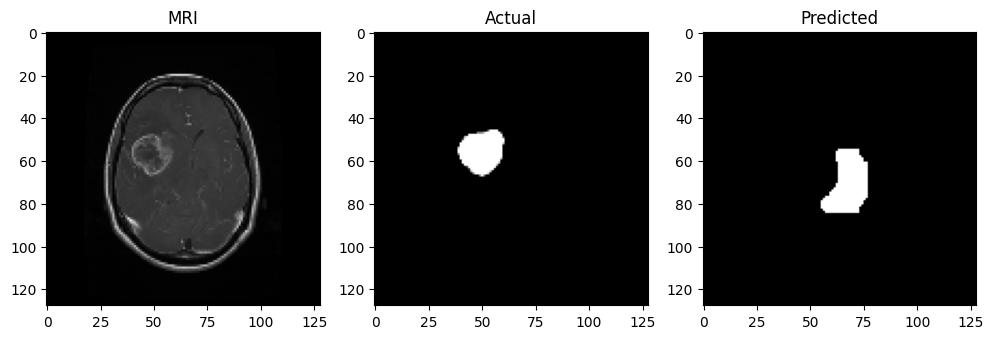

In [11]:
pred = model.predict(X_test)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("MRI")
plt.imshow(X_test[0])

plt.subplot(1,3,2)
plt.title("Actual")
plt.imshow(y_test[0].squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Predicted")
plt.imshow(pred[0].squeeze() > 0.3, cmap='gray')

plt.show()

#**Save model**

In [12]:
model.save("model.h5")